In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import seaborn as sns

In [2]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

In [3]:
adata=sc.read_loom('Dataset1_Pseudo_betas.loom') 
adata.obs_names=adata.obs.obs_names
adata.var_names=adata.var.gene_name
cond_=adata.obs[['Disease']]

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
pseudo=pd.DataFrame.sparse.from_spmatrix(adata.X, index=adata.obs.index, columns=adata.var_names)

In [5]:
pseudo

gene_name,LEF1,FOXJ2,MIR3123,ZNF654,TAL1,LOC728323,ZMYM2,CACNA1I,DCAF6,PDP1,...,ARHGAP26-IT1,GIPC2,PLEKHO1,CA14,MEIS1-AS2,NUDT15,LINC00564,LINC00557,RAI1-AS1,TMEM74B
obs_names,,,,,,,,,,,,,,,,,,,,,
Sample101,0,79.0,0,180.0,0,0,629.0,0,150.0,181.0,...,0,0,3.0,0,0,264.0,0,0,0,19.0
Sample102,28.0,336.0,0,194.0,0,0,895.0,0,663.0,525.0,...,0,8.0,179.0,0,10.0,934.0,0,0,0,118.0
Sample103,0,869.0,0,1298.0,0,0,2900.0,2.0,536.0,645.0,...,0,1.0,258.0,5.0,1.0,823.0,0,0,13.0,28.0
Sample104,0,599.0,0,523.0,0,0,2029.0,0,1042.0,647.0,...,2.0,0,56.0,7.0,3.0,1029.0,0,0,1.0,45.0
Sample105,0,1180.0,0,406.0,0,0,1664.0,15.0,1468.0,527.0,...,1.0,0,263.0,39.0,5.0,557.0,0,0,40.0,65.0
Sample106,0,129.0,0,297.0,0,0,1259.0,0,505.0,225.0,...,0,4.0,32.0,0,0,521.0,0,0,2.0,34.0
Sample107,0,88.0,0,62.0,27.0,0,324.0,0,14.0,19.0,...,0,0,0,13.0,1.0,40.0,0,0,0,0
Sample108,0,358.0,0,354.0,0,0,776.0,8.0,658.0,227.0,...,0,23.0,12.0,0,9.0,161.0,0,0,6.0,28.0
Sample109,0,1069.0,0,613.0,0,0,2149.0,1.0,1295.0,673.0,...,0,123.0,65.0,4.0,1.0,570.0,0,14.0,11.0,122.0


In [6]:
cond_

,Disease
obs_names,
Sample101,normal
Sample102,normal
Sample103,normal
Sample104,normal
Sample105,normal
Sample106,normal
Sample107,type II diabetes
Sample108,type II diabetes
Sample109,type II diabetes


# pyDEseq2

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [8]:
counts_=pseudo#df_norm
mdata_=cond_
#mdata_.index=adata.obs.index
#counts_=counts_.drop(columns=['Cond','SIG_basal_high'])
#counts_=counts_.loc[:, ~counts_.columns.duplicated()]

In [9]:
dds = DeseqDataSet(
    counts=counts_,
    metadata=mdata_,
    design_factors="Disease",
    refit_cooks=False,
    n_cpus=8,
)

C:\Users\Leo\AppData\Local\Temp\ipykernel_38596\556475287.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


In [10]:
dds.deseq2()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.99 seconds.

Fitting dispersion trend curve...
... done in 0.97 seconds.

Fitting MAP dispersions...
... done in 3.95 seconds.

Fitting LFCs...
... done in 3.63 seconds.

Calculating cook's distance...
... done in 0.05 seconds.



In [11]:
contrast = ['Disease', "normal", "type II diabetes"]

stat_res = DeseqStats(dds,contrast=contrast, n_cpus=8)

In [12]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Disease normal vs type II diabetes
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_name                                                                    
LEF1         3.101557        0.116946  2.955936  0.039563       NaN       NaN
FOXJ2      389.785326       -0.476313  0.399201 -1.193166  0.232804  0.538032
MIR3123      0.066155       -1.425900  3.446570 -0.413716  0.679082       NaN
ZNF654     291.752464        0.646641  0.607915  1.063703  0.287463  0.598684
TAL1         9.319001       -7.085811  3.162432 -2.240621       NaN       NaN
...               ...             ...       ...       ...       ...       ...
NUDT15     375.488934        1.501105  0.401014  3.743277  0.000182  0.008322
LINC00564    0.000000             NaN       NaN       NaN       NaN       NaN
LINC00557    0.615357       -3.350918  3.288024 -1.019128  0.308142       NaN
RAI1-AS1     4.201088        0.537185  1.598821  0.335989  0.736880  

... done in 2.22 seconds.



In [13]:
df_DE=stat_res.results_df

In [14]:
df_DE.to_csv('DE_dataset1_bulk.csv')

In [45]:
df_DE.sort_values('padj', ascending=True).to_excel('Suple/Table1.xlsx')

In [44]:
df_DE.sort_values('padj', ascending=True)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
GABRA2,134.591513,7.404099,0.811412,9.124962,7.176172e-20,1.068532e-15
IGFBP3,2925.874569,6.422239,0.739017,8.690248,3.616500e-18,2.692484e-14
TF,241.941483,7.932607,1.026934,7.724556,1.122436e-14,5.571024e-11
PCDH20,142.745902,10.238768,1.420350,7.208621,5.652136e-13,2.104008e-09
MSN,808.559226,-2.448783,0.342920,-7.140982,9.266652e-13,2.759609e-09
...,...,...,...,...,...,...
ARHGAP26-IT1,0.317736,-0.755717,3.200806,-0.236102,8.133535e-01,NaN
MEIS1-AS2,3.721718,-1.526920,1.322807,-1.154303,2.483758e-01,NaN
LINC00564,0.000000,NaN,NaN,NaN,NaN,NaN


In [16]:
df_DE.loc['CEBPG']

baseMean          2204.333237
log2FoldChange       1.354726
lfcSE                0.414026
stat                 3.272081
pvalue               0.001068
padj                 0.025806
Name: CEBPG, dtype: float64

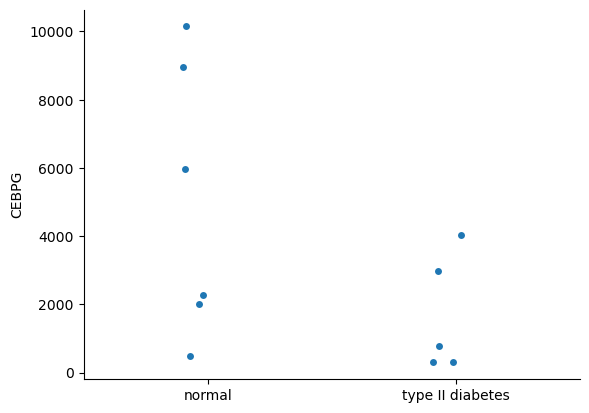

In [17]:
sns.stripplot(counts_,y='CEBPG', x=mdata_.Disease.values)
sns.despine()

In [18]:
# Known DE genes to check *IAPP*, *MAFA*, *PDX1*, *SLC2A2*, *FXYD2*, *STX1A*, *ATP2A2*, *PGRMC1*, and *LDHA*

In [19]:
df_DE[ (df_DE.log2FoldChange.abs()>1) & (df_DE.padj<0.05)]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
MARK1,781.659635,1.224413,0.364500,3.359157,7.818076e-04,0.021346
MOV10,212.447001,-1.513319,0.349910,-4.324879,1.526157e-05,0.001466
CWC15,1073.158377,1.029181,0.203796,5.050064,4.416612e-07,0.000094
RNF144A,41.097577,4.597770,1.280625,3.590255,3.303546e-04,0.012485
SMAD9,821.590154,2.332641,0.444059,5.253002,1.496399e-07,0.000039
...,...,...,...,...,...,...
SAPCD1-AS1,34.447255,-1.475703,0.433227,-3.406302,6.584927e-04,0.019578
PARP3,98.939968,-2.334383,0.694814,-3.359725,7.802007e-04,0.021346
NPLOC4,706.679913,-1.129319,0.333437,-3.386908,7.068508e-04,0.020231


In [20]:
df_DE.loc['FXYD2']

baseMean          243.915034
log2FoldChange      1.831159
lfcSE               0.453966
stat                4.033693
pvalue              0.000055
padj                0.003666
Name: FXYD2, dtype: float64

In [21]:
df_DE.loc['PDX1']

baseMean          1474.806227
log2FoldChange      -0.766341
lfcSE                0.333316
stat                -2.299139
pvalue               0.021497
padj                 0.156679
Name: PDX1, dtype: float64

In [22]:
df_DE.loc['STX1A']

baseMean          3412.379712
log2FoldChange      -1.139911
lfcSE                0.352203
stat                -3.236522
pvalue               0.001210
padj                 0.027932
Name: STX1A, dtype: float64

In [23]:
df_DE.loc['PGRMC1']

baseMean          2482.228550
log2FoldChange       1.373453
lfcSE                0.282203
stat                 4.866897
pvalue               0.000001
padj                 0.000199
Name: PGRMC1, dtype: float64

In [24]:
df_DE.loc['LDHA']

baseMean          946.984448
log2FoldChange      2.696845
lfcSE               0.834255
stat                3.232639
pvalue              0.001227
padj                0.028209
Name: LDHA, dtype: float64

In [25]:
# Genes used for experiments TMEM176A/B, DBI, CEBPG, DSTN, GABARAP, SPIRE1 and ATRAID

In [26]:
df_DE.loc['TMEM176A']

baseMean          1574.375304
log2FoldChange       1.510377
lfcSE                0.820785
stat                 1.840162
pvalue               0.065744
padj                 0.281190
Name: TMEM176A, dtype: float64

In [27]:
df_DE.loc['TMEM176B']

baseMean          2220.932935
log2FoldChange       1.181780
lfcSE                0.624472
stat                 1.892446
pvalue               0.058432
padj                 0.265501
Name: TMEM176B, dtype: float64

In [28]:
df_DE.loc['DBI']

baseMean          2608.824877
log2FoldChange       1.228992
lfcSE                0.449810
stat                 2.732246
pvalue               0.006290
padj                 0.075903
Name: DBI, dtype: float64

In [29]:
df_DE.loc['CEBPG']

baseMean          2204.333237
log2FoldChange       1.354726
lfcSE                0.414026
stat                 3.272081
pvalue               0.001068
padj                 0.025806
Name: CEBPG, dtype: float64

In [30]:
df_DE.loc['DSTN']

baseMean          9946.416018
log2FoldChange       0.475375
lfcSE                0.200171
stat                 2.374841
pvalue               0.017556
padj                 0.139125
Name: DSTN, dtype: float64

In [31]:
df_DE.loc['GABARAP']

baseMean          9839.642318
log2FoldChange       0.385869
lfcSE                0.197084
stat                 1.957897
pvalue               0.050242
padj                 0.244747
Name: GABARAP, dtype: float64

In [32]:
df_DE.loc['SPIRE1']

baseMean          1572.345974
log2FoldChange       0.541265
lfcSE                0.547854
stat                 0.987973
pvalue               0.323166
padj                 0.633400
Name: SPIRE1, dtype: float64

In [33]:
df_DE.loc['ATRAID']

baseMean          4668.169454
log2FoldChange      -0.316506
lfcSE                0.236348
stat                -1.339152
pvalue               0.180521
padj                 0.475577
Name: ATRAID, dtype: float64

In [34]:
# Genes used for experiments in figure 6

In [35]:
df_DE.loc['KIAA1324']

baseMean          6485.397951
log2FoldChange      -0.442129
lfcSE                0.243284
stat                -1.817335
pvalue               0.069166
padj                 0.289536
Name: KIAA1324, dtype: float64

In [36]:
df_DE.loc['RPS3']

baseMean          11312.287362
log2FoldChange        0.116712
lfcSE                 0.139463
stat                  0.836863
pvalue                0.402670
padj                  0.699817
Name: RPS3, dtype: float64